# Import libraries

In [3]:
from src.utils import load_data, split_input_output, split_train_test, serialize_data, deserialize_data
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [4]:
with open('../config/path.yaml', 'r') as f:
    path = yaml.safe_load(f)

X_TRAIN_PATH = path['data_path']['input']['X_train']
Y_TRAIN_PATH = path['data_path']['output']['y_train']

In [5]:
print(f"X train path : {X_TRAIN_PATH}")
print(f"y train path : {Y_TRAIN_PATH}")

X train path : ../data/interim/X_train.pkl
y train path : ../data/interim/y_train.pkl


In [6]:
X_train = deserialize_data(X_TRAIN_PATH)
X_train.head(5)

Succeed to deserialize data


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15884,25,241875,MORTGAGE,4.0,EDUCATION,A,16000,7.05,0.07,N,4
15138,21,18000,RENT,5.0,PERSONAL,B,1500,12.18,0.08,N,4
7474,25,53000,MORTGAGE,10.0,MEDICAL,B,16000,12.53,0.30,N,2
18212,28,16800,OWN,NaN,MEDICAL,C,5000,13.98,0.30,N,8
6493,25,50000,MORTGAGE,2.0,VENTURE,A,10000,7.90,0.20,N,2


In [7]:
y_train = deserialize_data(Y_TRAIN_PATH)
y_train.head(5)

Succeed to deserialize data


15884    0
15138    1
7474     0
18212    1
6493     0
Name: loan_status, dtype: int64

## Identifikasi kolom kategorik dan numerik

In [8]:
X_train.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15884,25,241875,MORTGAGE,4.0,EDUCATION,A,16000,7.05,0.07,N,4
15138,21,18000,RENT,5.0,PERSONAL,B,1500,12.18,0.08,N,4
7474,25,53000,MORTGAGE,10.0,MEDICAL,B,16000,12.53,0.30,N,2
18212,28,16800,OWN,NaN,MEDICAL,C,5000,13.98,0.30,N,8
6493,25,50000,MORTGAGE,2.0,VENTURE,A,10000,7.90,0.20,N,2


In [9]:
X_train.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [10]:
num_col = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_col = ['person_home_ownership', 'loan_intent','loan_grade','cb_person_default_on_file']

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26064 non-null  int64  
 1   person_income               26064 non-null  int64  
 2   person_home_ownership       26064 non-null  object 
 3   person_emp_length           25326 non-null  float64
 4   loan_intent                 26064 non-null  object 
 5   loan_grade                  26064 non-null  object 
 6   loan_amnt                   26064 non-null  int64  
 7   loan_int_rate               23563 non-null  float64
 8   loan_percent_income         26064 non-null  float64
 9   cb_person_default_on_file   26064 non-null  object 
 10  cb_person_cred_hist_length  26064 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 2.4+ MB


Note: 

    Kesimpulan :
        - Data numerical memilki tipe int64 / float64, sedangkan data categorical memiliki tipe object.

    Tindakan selanjutnya :
        - EDA.
        - Imputasi data seperting missing value, duplicate, etc.
        - Melakukan Encode pada data dengan tipe categorical.
        - Join data numerical dan categorical.
        - Scaling dan Transform.

## Pengecekan Data Duplikat

In [12]:
X_train.duplicated(keep= False)

15884    False
15138    False
7474     False
18212    False
6493     False
         ...  
14621    False
18736    False
1663     False
18257    False
17068    False
Length: 26064, dtype: bool

In [13]:
print(sum(X_train.duplicated(keep= False)))

192


In [14]:
X_train.sort_values(by= 'person_income')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
31930,41,4000,RENT,0.0,MEDICAL,C,2000,13.22,0.50,Y,15
15964,21,4080,RENT,0.0,EDUCATION,B,1400,11.86,0.34,N,4
27896,32,4200,RENT,NaN,PERSONAL,C,1200,12.73,0.29,N,9
15963,21,4200,RENT,3.0,PERSONAL,E,2750,16.95,0.65,N,3
15961,22,4800,RENT,0.0,MEDICAL,C,1200,14.26,0.25,Y,2
...,...,...,...,...,...,...,...,...,...,...,...
17833,32,1200000,MORTGAGE,1.0,VENTURE,A,12000,7.51,0.01,N,8
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0.00,N,15
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0.01,N,30
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0.00,Y,15


Note :

    Kesimpulan :
        - Sangat umum terjadi data duplikat pada raw data, kita bisa gunakan fungsi duplicated() pada pandas dataframe untuk mengecek apakah ada data kita yang terduplikat dan berapa jumlahnya.

    Tindakan Selanjutnya :
        - Karena data duplikat yang dimiliki jumlahnya sangat kecil dari data keseluruhan maka kita bisa drop data yang duplikat (tidak perlu investigasi mendalam)

## Pengecekan Data Null

In [15]:
X_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              738
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2501
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Note :

    Kesimpulan : 
        - Terdapat 2 kolom yang memilki data data null yaitu person_emp_length dan loan_int_rate, dan kolom loan_int_rate memiliki jumlah data null yang paling banyak

    Tindakan selanjutnya :
        - Melihat distribusi data pada kedua kolom tersebut untuk menentukan langkah imputasi yang akan dilakukan.

## Pengecekan Distribusi pada Tiap Input

In [16]:
X_train_ = X_train.copy()
X_train_.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15884,25,241875,MORTGAGE,4.0,EDUCATION,A,16000,7.05,0.07,N,4
15138,21,18000,RENT,5.0,PERSONAL,B,1500,12.18,0.08,N,4
7474,25,53000,MORTGAGE,10.0,MEDICAL,B,16000,12.53,0.30,N,2
18212,28,16800,OWN,NaN,MEDICAL,C,5000,13.98,0.30,N,8
6493,25,50000,MORTGAGE,2.0,VENTURE,A,10000,7.90,0.20,N,2


In [17]:
X_train_ = X_train_[num_col]
X_train_.head(5)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
15884,25,241875,4.0,16000,7.05,0.07,4
15138,21,18000,5.0,1500,12.18,0.08,4
7474,25,53000,10.0,16000,12.53,0.30,2
18212,28,16800,NaN,5000,13.98,0.30,8
6493,25,50000,2.0,10000,7.90,0.20,2


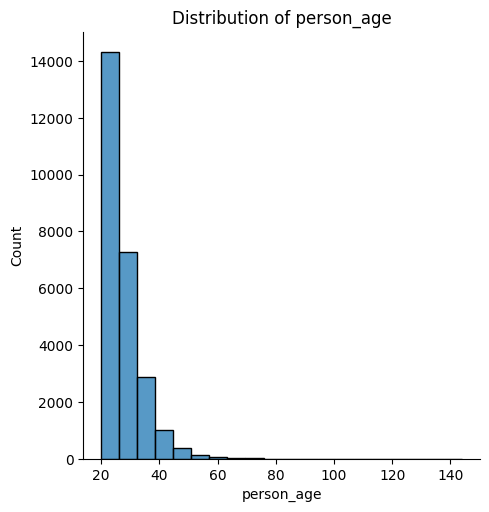

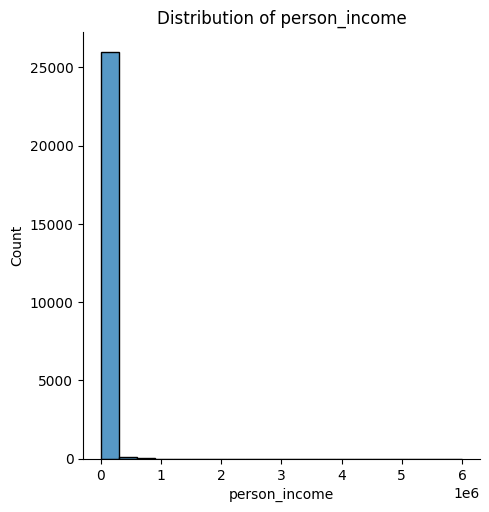

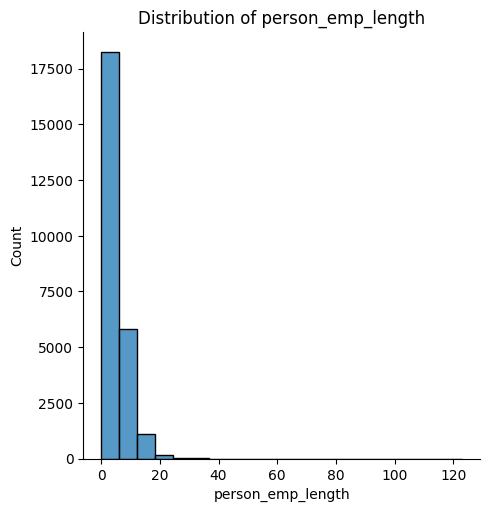

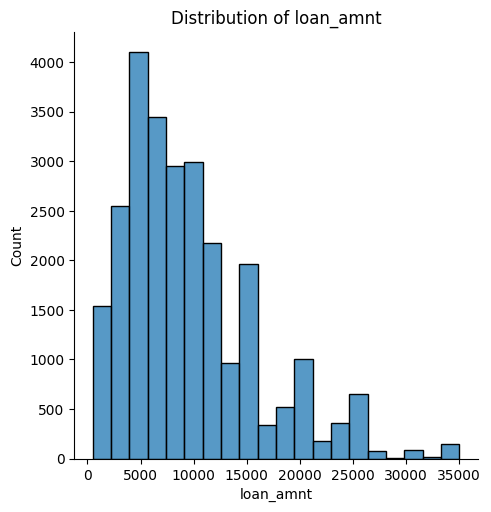

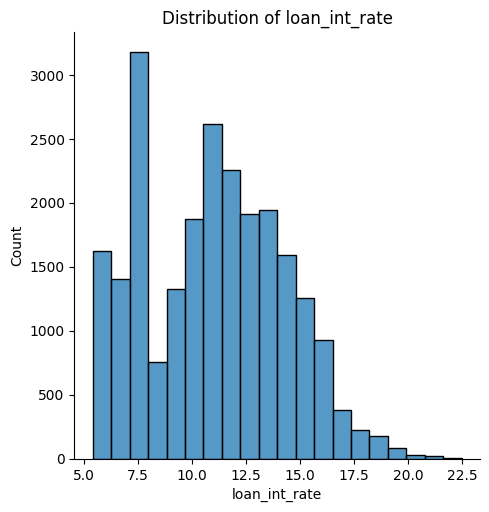

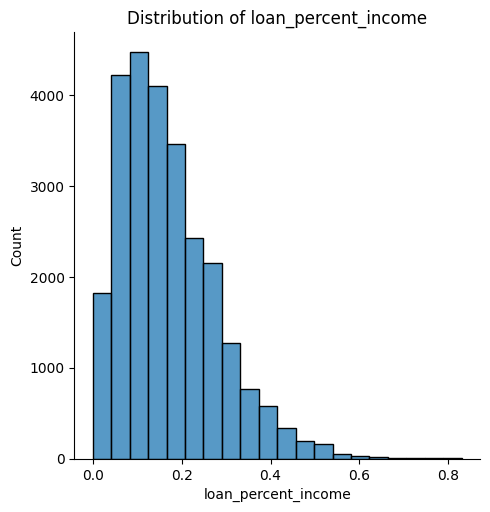

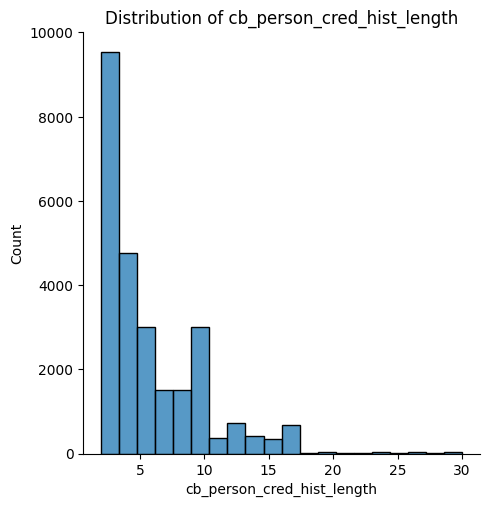

In [18]:
for col in X_train_.columns:
    sns.displot(data= X_train_, x= col, bins= 20)
    plt.title(f"Distribution of {col}")  

Note :

    Kesimpulan :
        - Hampir dari semua kolom memiliki data yang skew, maka harus lebih hati - hati dalam mengambil tindakan di preprocessing baik dalam menangani anomali ataupun imputasi.

    Tindakan selanjutnya :
        - Pada distribusi person_age harus dicek berapa usia wajar seseorang untuk mengajukan kredit, semisal minimal 18 tahun karena dianggap produktif dan maksimal 60 tahun (mengikuti umur pensiun pekerja pada umumnya), maka untuk data di luar range tersebut bisa dihilangkan / drop. (Sangat baik untuk dilakukan)
        - Pada distribusi person_income harus dicek berapa penghasilan minimal untuk bisa mengajukan kredit dan berapa pendapat maksimal untuk mengecek apakah wajar orang dengan pendapatan tersebut mengajukan kredit, di luar range tersebut bisa dihilangkan / drop. (Tidak wajib, tapi bisa menjadi opsi)
        - Pada distribusi person_emp_length harus dicek berapa maksimal employment length yang wajar, karena jumlah maksimal person_emp_length menyentuh 120 tahun maka harus ditentukan batas maksimal employment length yang wajar untuk menghindari data tidak valid. Untuk data dengan employment length di atas batas maksimal bisa dihilangkan / drop, dan melakukan imputasi dengan menggunakan median karena robust. (Sangat baik untuk dilakukan)
        - Pada distribusi loan_int_rate dapat digunakan sebagai acuan untuk imputasi data null, menggunakan median karena robust. (Sangat baik untuk dilakukan)

## Pengecekan Target Balance

In [19]:
y_train.head(5)

15884    0
15138    1
7474     0
18212    1
6493     0
Name: loan_status, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

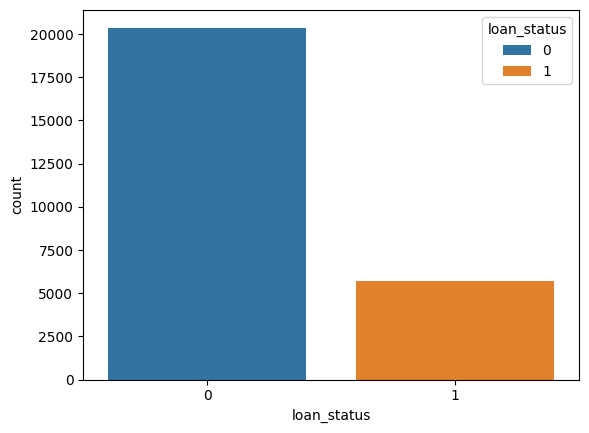

In [20]:
sns.countplot(x= y_train, hue= y_train)

Note :

    Kesimpulan :
        - Data target (output) memiliki jumlah yang tidak seimbang antara 0 dan 1, hal ini akan menentukan bagaimana cara menghandel data tidak seimbang.

    Tindakan selanjutnya :
        - Melakukan balancing, menggunakan SMOTE (Syntethic Minority Over-sampling Technique) atau ROS (Random Over-Sampling) supaya tidak mereduce jumlah data loan_status dengan nilai 0.

Rangkuman Kesimpulan :
    
    - Tipe data yang lumrah ditemui untuk data numerik adalah int64 / float64 dan untuk data kategorik adalah object.
    - Data duplikat akan sering dijumpai pada data raw, pastikan persentase seberapa banyak data duplikat dari total data, dan jika jumlahnya kecil maka bisa langsung dihilangkan / drop.
    - Jika ada data null, maka kita harus cek distribusi pada kolom terkait untuk menentukan langkah imputasi yang akan diambil, lumrahnya untuk data numerik menggunakan median karena robust terhadap data skew.
    - Penting untuk mengecek distribusi dari setiap data numerik secara visual untuk identifikasi anomali dan menentukan langkah penanganannya, dan berguna untuk menentukan langkah imputasi pada data null.
    - Terjadi data yang tidak seimbang pada data target, harus dilakukan balancing.